In [85]:
import sys
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

E:\My codes\Medical AI\lung-ai-platform


In [86]:
from backend.preprocessing.patch_sampler import PatchSampler
from backend.datasets.lidc_dataset import LIDCDataset

sampler = PatchSampler()

dataset = LIDCDataset(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri",
    sampler=sampler,
)

print(len(dataset))

600


In [87]:
sample = dataset[0]

print(sample.keys())

dict_keys(['image', 'mask', 'patient_id', 'center', 'patch_bbox', 'is_positive'])


In [88]:
print(sample["image"].shape)
print(sample["mask"].shape)

torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])


In [89]:
print(sample["image"].dtype)
print(sample["mask"].dtype)

torch.float32
torch.float32


In [90]:
print(sample["mask"].min())
print(sample["mask"].max())

tensor(0.)
tensor(1.)


In [91]:
import time

t = time.time()
sample = dataset[0]
print("First:", time.time() - t)

t = time.time()
sample = dataset[1]
print("Second:", time.time() - t)

First: 0.20064759254455566
Second: 0.17534518241882324


In [92]:
from backend.training.dataloader import create_train_loader
loader = create_train_loader(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)

In [93]:
print(batch["image"].shape)
print(batch["mask"].shape)

torch.Size([2, 1, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


In [94]:
image = sample["image"][0]
mask = sample["mask"][0]

In [95]:

loader = create_train_loader(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri",
    batch_size=2,
    patch_size=(128, 128, 128),
    positive_ratio=0.7,
    offset=(12, 12, 6),
    patches_per_patient=20,
    num_workers=0,
)

print(loader)

In [96]:
sample = dataset[0]

In [97]:
image = sample["image"][0].numpy()
mask = sample["mask"][0].numpy()

In [98]:
mid = image.shape[0] // 2

print(mid)

64


In [99]:
import numpy as np

slices = np.where(mask.sum(axis=(1,2)) > 0)[0]

print(slices)

[57 58 59 60 61 62 63 64 65]


In [100]:
print(sample["is_positive"])
print(mask.sum())

True
6547.0


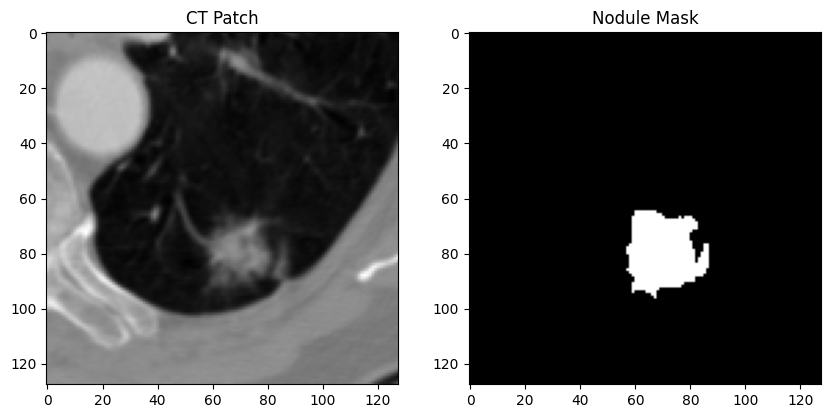

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image[mid], cmap="gray")
plt.title("CT Patch")

plt.subplot(1,2,2)
plt.imshow(mask[mid], cmap="gray")
plt.title("Nodule Mask")

plt.show()

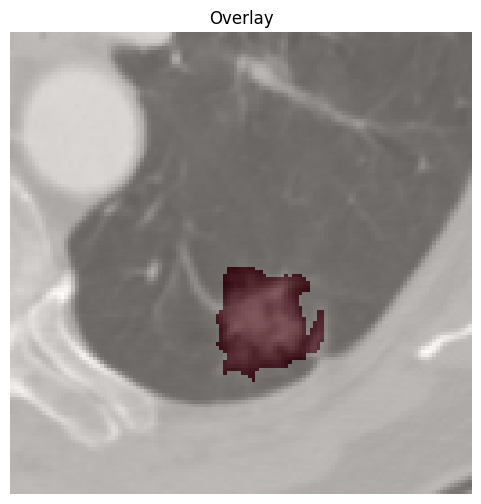

In [102]:
plt.figure(figsize=(6,6))

plt.imshow(image[mid], cmap="gray")
plt.imshow(mask[mid], cmap="Reds", alpha=0.4)

plt.title("Overlay")
plt.axis("off")

plt.show()